In [2]:
# ==========================================
# GUACAMAIA: Tourism Demand Intelligence
# Exploratory Data Analysis (EDA)
# ==========================================

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# GuacamaIA Premium Tropical Palette

PRIMARY_COLOR = "#0077B6"      # deep ocean blue (trust, data)
ACCENT_COLOR = "#00B4D8"       # tropical turquoise (fresh, travel)
HIGHLIGHT_COLOR = "#FFD166"    # warm sand/gold (luxury touch)
NEUTRAL_DARK = "#1E1E1E"       # text / contrast
BACKGROUND_LIGHT = "#F4F1EC"   # soft sand background

plt.style.use("default")

In [5]:
# Load the hotel booking dataset from the raw data folder
# This dataset contains booking information such as dates, prices, and customer details
df = pd.read_csv("../data/raw/hotel_bookings.csv")

# Display the first rows to understand the structure of the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
# Check the shape of the dataset (rows, columns)
# This tells us how large the dataset is
df.shape


(119390, 32)

In [7]:
# Inspect data types and missing values
# Important to understand data quality before modeling
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
# Combine year, month, and day into a single datetime column
# This is essential for time series analysis and forecasting

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

# Verify the new datetime column
df[['arrival_date']].head()

,arrival_date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01


In [9]:
# Aggregate data at the daily level
# We count how many bookings occur per day

demand_df = df.groupby('arrival_date').size().reset_index(name='bookings')

# Preview the aggregated dataset
demand_df.head()

,arrival_date,bookings
0,2015-07-01,122
1,2015-07-02,93
2,2015-07-03,56
3,2015-07-04,88
4,2015-07-05,53


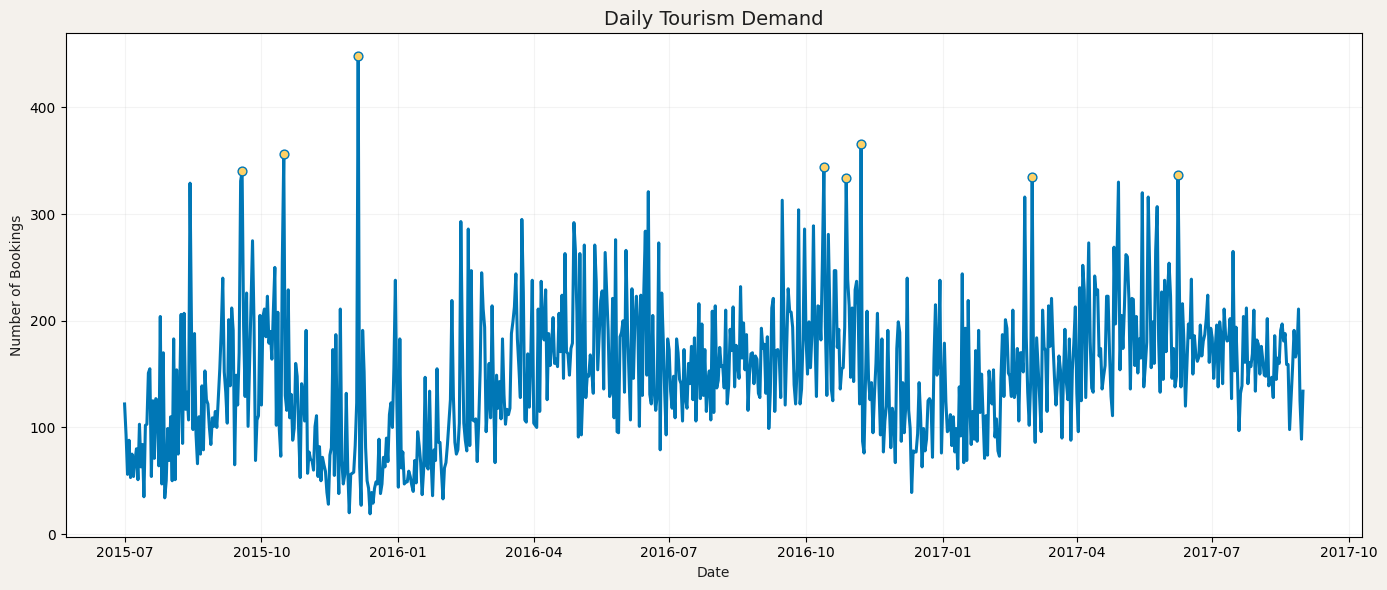

In [10]:
# Plot daily tourism demand with highlighted peak periods

plt.figure(figsize=(14,6), facecolor=BACKGROUND_LIGHT)

plt.plot(
    demand_df['arrival_date'],
    demand_df['bookings'],
    color=PRIMARY_COLOR,
    linewidth=2.2
)

# Highlight peak demand points (top 1%)
threshold = demand_df['bookings'].quantile(0.99)
peaks = demand_df[demand_df['bookings'] >= threshold]

plt.scatter(
    peaks['arrival_date'],
    peaks['bookings'],
    color=HIGHLIGHT_COLOR,
    edgecolor=PRIMARY_COLOR,
    s=40,
    zorder=3
)

plt.title("Daily Tourism Demand", fontsize=14, color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("Number of Bookings", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [11]:
# Extract time-based features from the datetime column
# These features help us understand seasonality patterns

demand_df['year'] = demand_df['arrival_date'].dt.year
demand_df['month'] = demand_df['arrival_date'].dt.month
demand_df['day_of_week'] = demand_df['arrival_date'].dt.dayofweek

demand_df.head()

,arrival_date,bookings,year,month,day_of_week
0,2015-07-01,122,2015,7,2
1,2015-07-02,93,2015,7,3
2,2015-07-03,56,2015,7,4
3,2015-07-04,88,2015,7,5
4,2015-07-05,53,2015,7,6


In [12]:
# Aggregate bookings by month to analyze seasonality

monthly_demand = demand_df.groupby('month')['bookings'].mean()

monthly_demand

month
1      95.629032
2     141.543860
3     157.967742
4     184.816667
5     190.177419
6     182.316667
7     136.139785
8     149.215054
9     175.133333
10    180.000000
11    113.233333
12    109.354839
Name: bookings, dtype: float64

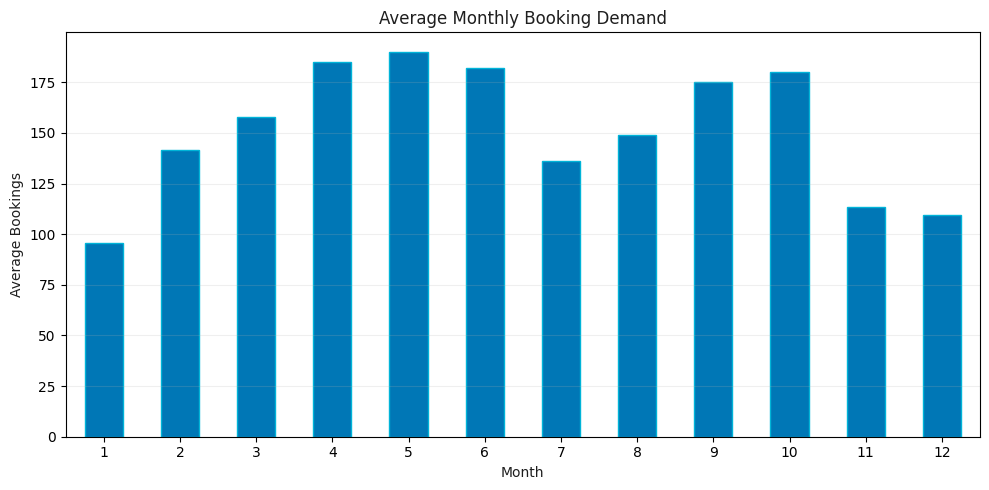

In [13]:
# Plot average monthly tourism demand

monthly_demand.plot(
    kind='bar',
    figsize=(10,5),
    color=PRIMARY_COLOR,
    edgecolor=ACCENT_COLOR
)

plt.title("Average Monthly Booking Demand", color=NEUTRAL_DARK)
plt.xlabel("Month", color=NEUTRAL_DARK)
plt.ylabel("Average Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
# KPI 1: Total number of bookings
total_bookings = len(df)

# KPI 2: Cancellation rate
cancellation_rate = df['is_canceled'].mean()

# KPI 3: Average daily rate (price)
average_price = df['adr'].mean()

# Display KPIs
total_bookings, cancellation_rate, average_price

(119390, np.float64(0.37041628277075134), np.float64(101.83112153446687))

In [15]:
# Aggregate total bookings per month
monthly_bookings = df.groupby('arrival_date_month').size().sort_values(ascending=False)

monthly_bookings

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
dtype: int64

In [16]:
# Identify top countries by booking volume
top_countries = df['country'].value_counts().head(10)

top_countries

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [17]:
# Cancellation rate by hotel type
cancellation_by_hotel = df.groupby('hotel')['is_canceled'].mean()

cancellation_by_hotel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

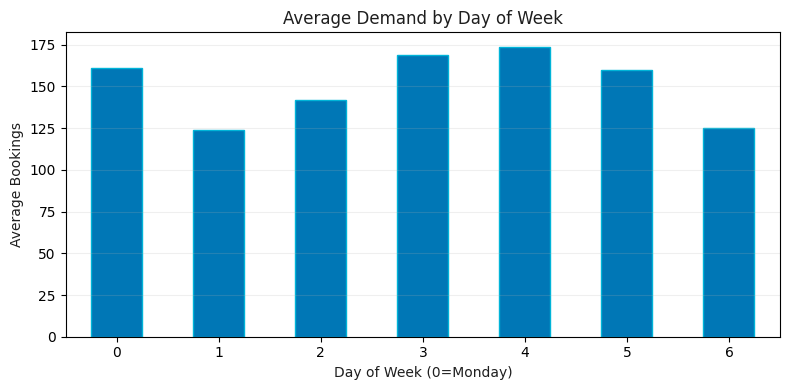

In [18]:
# Analyze demand by day of week

weekly_demand = demand_df.groupby('day_of_week')['bookings'].mean()

weekly_demand.plot(
    kind='bar',
    figsize=(8,4),
    color=PRIMARY_COLOR,
    edgecolor=ACCENT_COLOR
)

plt.title("Average Demand by Day of Week", color=NEUTRAL_DARK)
plt.xlabel("Day of Week (0=Monday)", color=NEUTRAL_DARK)
plt.ylabel("Average Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

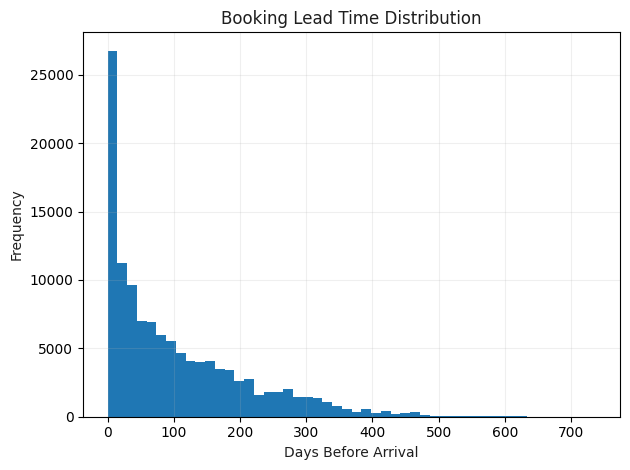

In [19]:
# Analyze booking lead time distribution

df['lead_time'].hist(bins=50)

plt.title("Booking Lead Time Distribution", color=NEUTRAL_DARK)
plt.xlabel("Days Before Arrival", color=NEUTRAL_DARK)
plt.ylabel("Frequency", color=NEUTRAL_DARK)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

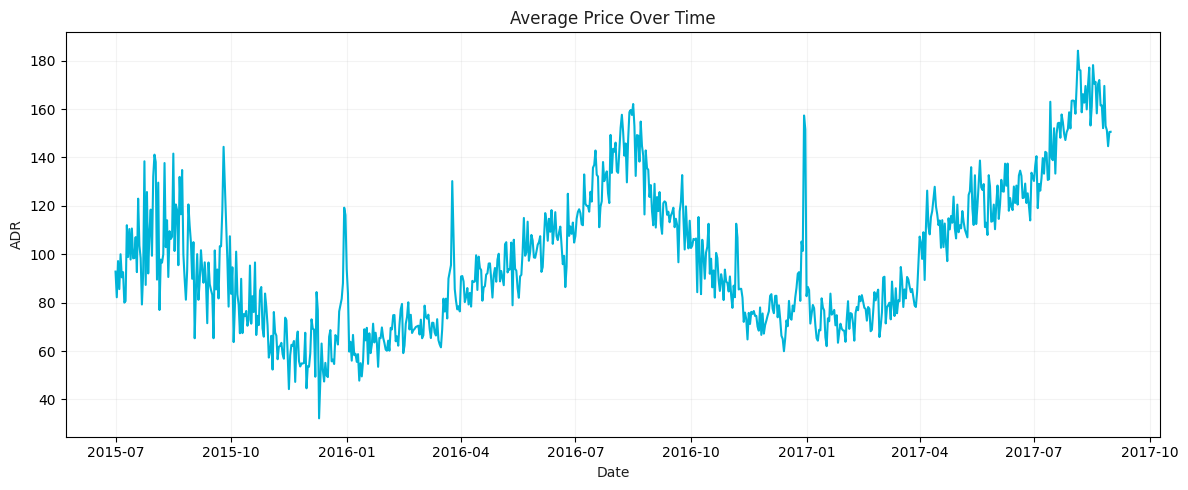

In [20]:
# Average price over time

price_trend = df.groupby('arrival_date')['adr'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(price_trend['arrival_date'], price_trend['adr'], color=ACCENT_COLOR)

plt.title("Average Price Over Time", color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("ADR", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

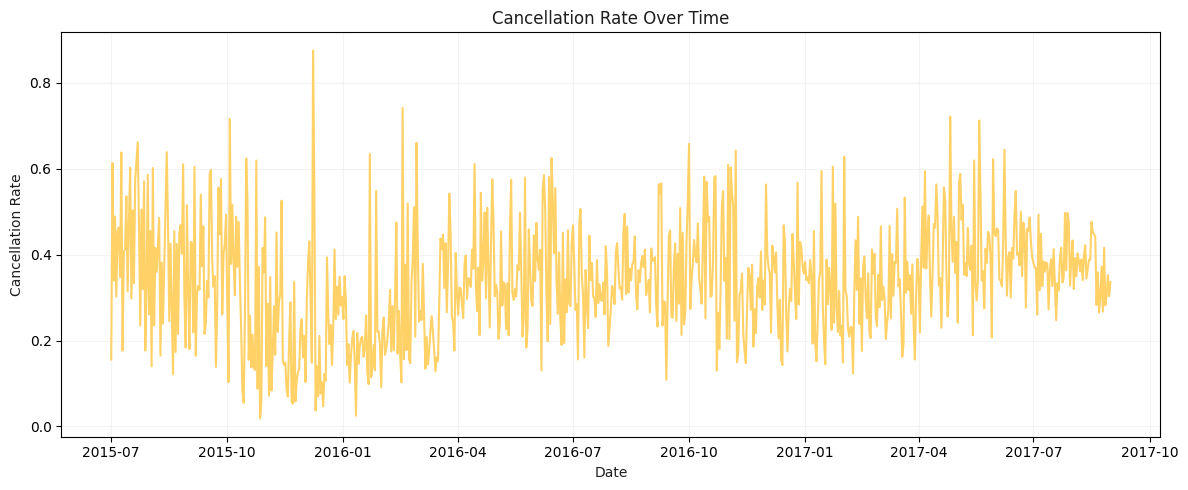

In [21]:
# Cancellation rate over time

cancel_trend = df.groupby('arrival_date')['is_canceled'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(cancel_trend['arrival_date'], cancel_trend['is_canceled'], color=HIGHLIGHT_COLOR)

plt.title("Cancellation Rate Over Time", color=NEUTRAL_DARK)
plt.xlabel("Date", color=NEUTRAL_DARK)
plt.ylabel("Cancellation Rate", color=NEUTRAL_DARK)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

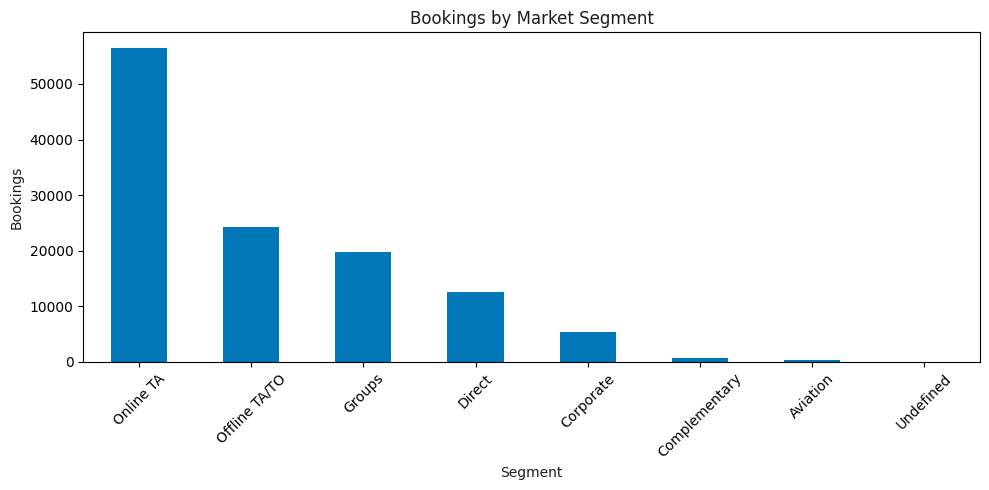

In [22]:
# Demand by market segment

segment_demand = df['market_segment'].value_counts()

segment_demand.plot(
    kind='bar',
    figsize=(10,5),
    color=PRIMARY_COLOR
)

plt.title("Bookings by Market Segment", color=NEUTRAL_DARK)
plt.xlabel("Segment", color=NEUTRAL_DARK)
plt.ylabel("Bookings", color=NEUTRAL_DARK)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
Maia = r"""
                                                          $& n/\\\\\\\\\\J        
                                                   $z\t\//////\\\\\\\\|||({(J     
                                              *Y)|(\q\/\\\/\\\/\\\||\\||\\(-_+_Y  
                                           vzft\/cmf\{{111111ii>~+-[||)-~++~<<<_v 
                                        $z|)[\t///t|-_-------<<:,,;i?_++<i>><<<<_ 
                                       bJ1-1ft/tt\({?Xa#MMMW&B%),,^^;~+<l!i>><<~~ 
                                     Y\~_}t///\))[?}*BQXnjuBB@@B@Oi^",;;l_[[[11)Q 
                                    8c}}{)/\/t[-_/JWBc;`''^<v@@#Wacx+";i]{{{1cc   
                                   Jt{tttt//){?-?ZB@B+-:i}v"]C[~LBB@j"+}1{{{{1)b  
                                  O[-\//ttt(!l-pB%hmB_~:'''itBQ-O@@Bj"}){{1{}[[t8 
                                xr-~_|txzYUct(;[M%x~uZzvccQ8BCfzh@@@f,}11{{{{]?~(w
                               z/?+1(/vLQQQQQJ^`"1BBi1|tfff\)f08]q@@t,}{1{{{{]]++t
                              |]_~?tt/CQ000QQQQJO_`XB@8&WWWMM];`joB%j:?)111{{]]++_
                             j_+?|t/ttLQQQQQQQLL>"/i^,I>>>l<L&&a@WqO{I:?)111{]]~~+
                             [++?\/t/tzQQ0QQL0JU^`"IJZp****o&@$@@p1>i!^_111{{]?~~_
                             __)\/////tjzLCQLz[I``>#@@@@@@@@@@@@uii!>i":?1111??~~+
                             __)/t//////jxvuu~;,^^<8@BB@@@@@@@MW)iii>i>',?11{]?~~+
                             _++}//////////t\[--<,"<mB@@@@@@@%z+iiiiii>!^^;?{??~~~
                           J]++(\\t/////\//|+_+>"```p%BBBB@@%v)>iiiiii>iI"^"l++<<{
                           ___?|/\/////////|[__iII`^`]0O#BooM]>>>iiiiiiiii:^l++<-(
                           j__]//\////////\/t1]]_!"`'\OOZZJY0->>iiiii>iii!;il++<z&
                         ||+_++-}//\////////{+_~;,^```"^``jJC-iiiiiiiiii>rQWY~~r  
                         +_~~_+[)\///\////\\)[]?_-~"`''`'';lli>i>><ii!\rO  &Y~+n  
                         __<<~~--+_|\////////\|1_+i,```''`````'``'`"lp     o0cc   
                       tCY-<~<<~~+]/\////////|\|))(<^^^```'````^`^$               
                      /_++<~~<<~~~?[?|\|\\//\\\\t\\~:+;`''^'````'"                
                   c?j1++++++++~~<<~~?-~?[[{\/////\_?};"!>;`'```-Q                
                  r-__+++_++++-__~<<<~+++++]//////\\(}i+__~!:```                  
                c}__+_++++++_+_-})()1~++++-1//////\\\(11]-+<i^`"                  
               On_+_++++++++_+{(\\\|\[++-{\///////\\\|\|{}-~<I;:                  
             u]___+_++__~++-\\t//t\t\(++?)\/\//\nZkpQJt\\\-_~+>i                  
             ?+_+++_++?(}[]}\\\/\/\||[++?1/\njffcqooabf\\\){[~<>                  
          f}-__+++]|///\////\]_1\/)]?J|_?}(/pahaooaoobt|(|/\)~~+$                 
         /-_+_}1))|////t\\/\-]___1+-)0(+-|qw1(qkhaa*oaqqmZj//{++$                 
        |+__+_)\tt///\11//\)_tX1_+_|xm(??toh/{((\Jaooaoakbnft)~~$                 
       \_~_[[}|////t/|?+][[_{zqZn1)jzq)?])XYtzunu0pqaaooahUzc\~~$                 
      (_++_)///\|\//\1--}}1/rCkhdJJqdZ[]]]??u**oahn|Qwdooooaau~+$                 
      -___[|\\\\1-{/\[+{ruurn0baaoaha1-][[]?rbbbhkx}[[ca*o*aan~?$                 
   \\~_{\/\/\\({?+_{{[XbUvnnxpQaaa*o0[}LCu]?]???nmkd|[cao**oon]X                  
  %+++}\/\|\\\{?[vu/fvZhhkbbkz]Zkoauj-[||rJJ)-]-jmhabbbUXLh*on_                   
  J??])\/(]{/|]?1mZxrcwkaaaooc}/cmJnj+}|/rLL|??-/U0Lhokctndkkx_                   
Y}]\//\/|]_+-{\/xddXu0hxqooooj)jjfjj/~}\\\|/zYu}_-__jnXO/}]?-??                   
{_}\///\(+1rjfffubhkkad_Uwaop(\rrfjt|_{\///tOqQ1____+_|pdpqqp\t                   
-_{\\]}(-[cwpZLLOaa*ooO[[}(r)\xrj|i+}/t///\/\/(||\]_+_]x0w0QQp&                   
1+(1]-+_1jUpkhaapxw**hu{{{{1{jrxf-,;?\///\/|t\jXCL}-_~_{zJ{-{$                    
"""

print("="*70)
print("GUACAMAIA — EDA COMPLETE")
print("="*70)
print(Maia)

GUACAMAIA — EDA COMPLETE

                                                          $& n/\\\\\\\\\\J        
                                                   $z\t\//////\\\\\\\\|||({(J     
                                              *Y)|(\q\/\\\/\\\/\\\||\\||\\(-_+_Y  
                                           vzft\/cmf\{{111111ii>~+-[||)-~++~<<<_v 
                                        $z|)[\t///t|-_-------<<:,,;i?_++<i>><<<<_ 
                                       bJ1-1ft/tt\({?Xa#MMMW&B%),,^^;~+<l!i>><<~~ 
                                     Y\~_}t///\))[?}*BQXnjuBB@@B@Oi^",;;l_[[[11)Q 
                                    8c}}{)/\/t[-_/JWBc;`''^<v@@#Wacx+";i]{{{1cc   
                                   Jt{tttt//){?-?ZB@B+-:i}v"]C[~LBB@j"+}1{{{{1)b  
                                  O[-\//ttt(!l-pB%hmB_~:'''itBQ-O@@Bj"}){{1{}[[t8 
                                xr-~_|txzYUct(;[M%x~uZzvccQ8BCfzh@@@f,}11{{{{]?~(w
                               z/?+1(/vLQQQQQJ^`"1BBi1|tfff\)

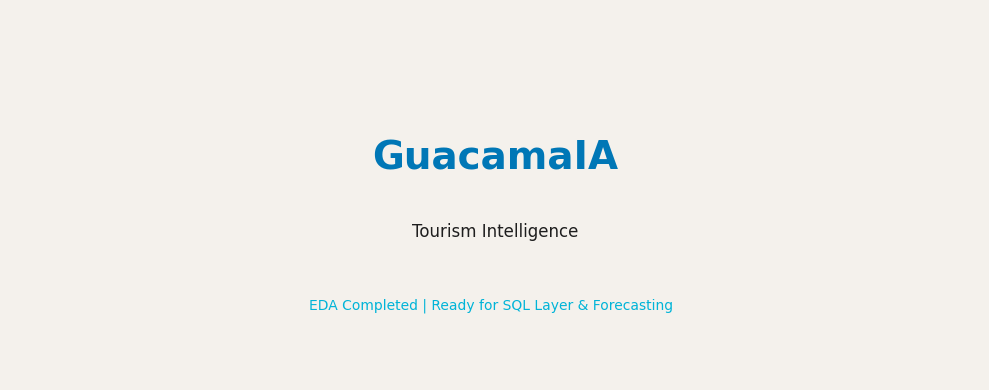

In [24]:
plt.figure(figsize=(10,4), facecolor=BACKGROUND_LIGHT)

plt.text(
    0.5, 0.6,
    "GuacamaIA",
    fontsize=28,
    color=PRIMARY_COLOR,
    ha='center',
    va='center',
    fontweight='bold'
)

plt.text(
    0.5, 0.4,
    "Tourism Intelligence",
    fontsize=12,
    color=NEUTRAL_DARK,
    ha='center',
    va='center'
)

plt.text(
    0.5, 0.2,
    "EDA Completed | Ready for SQL Layer & Forecasting  ",
    fontsize=10,
    color=ACCENT_COLOR,
    ha='center',
    va='center'
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
# ==========================================
# SQL LAYER — Tourism Demand Analysis
# ==========================================

In [26]:
# Initialize SQL connection

import sqlite3

conn = sqlite3.connect("../data/tourism.db")

print("SQL connection established")

SQL connection established


In [27]:
# Load dataframe into SQL database

df.to_sql("bookings", conn, if_exists="replace", index=False)

print("Table 'bookings' created in SQL database")

Table 'bookings' created in SQL database


In [28]:
# Monthly demand 

query = """
SELECT 
    arrival_date_month,
    COUNT(*) AS total_bookings
FROM bookings
GROUP BY arrival_date_month
ORDER BY total_bookings DESC;
"""

monthly_sql = pd.read_sql(query, conn)
monthly_sql

,arrival_date_month,total_bookings
0,August,13877
1,July,12661
2,May,11791
3,October,11160
4,April,11089
5,June,10939
6,September,10508
7,March,9794
8,February,8068
9,November,6794


In [ ]:
# Cancellation rate 

query = """
SELECT 
    ROUND(AVG(is_canceled), 3) AS cancellation_rate
FROM bookings;
"""

pd.read_sql(query, conn)

,cancellation_rate
0,0.37


In [30]:
# Top countries by demand

query = """
SELECT 
    country,
    COUNT(*) AS bookings
FROM bookings
GROUP BY country
ORDER BY bookings DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,country,bookings
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104
